In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import tensorflow_datasets as tfds

from model_service.config import ModelServiceConfig

config = ModelServiceConfig()

# This is the "Magic" line - we point directly to where you just showed me the data is
DATA_PATH = "/Users/shayan/tensorflow_datasets"

# 1. Load Data Splits using your specific root path
# 'download=False' is now safe because we know the path is correct
train_raw, val_raw = tfds.load(
    "patch_camelyon",
    data_dir=DATA_PATH,
    split=['train', 'validation'],
    as_supervised=True,
    download=False
)

# 2. Fast Preprocessing Function
def prepare_image(image, label):
    # Matches your config.data.image_size (96)
    image = tf.image.resize(image, (config.data.image_size, config.data.image_size))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, tf.cast(label, tf.float32)

# 3. Build Pipelines
autotune = tf.data.AUTOTUNE

# Take 25k for the bootcamp demo speed
train_ds = train_raw.shuffle(10000).take(25000).map(prepare_image, num_parallel_calls=autotune)

# IMPORTANT: cache() before repeat() saves the processed images in RAM
# so your Mac doesn't have to re-calculate pixels every epoch.
train_ds = train_ds.cache().repeat().batch(config.data.batch_size).prefetch(autotune)

val_ds = val_raw.take(5000).map(prepare_image, num_parallel_calls=autotune)
val_ds = val_ds.batch(config.data.batch_size).cache().prefetch(autotune)

print(f"✅ Success! Data loaded from {DATA_PATH}")

✅ Success! Data loaded from /Users/shayan/tensorflow_datasets


In [ ]:
from tensorflow.keras import layers, models

def build_pathsight_model():
    base_model = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_shape=(config.data.image_size, config.data.image_size, 3)
    )

    # Let's unfreeze the whole thing but keep learning rate low
    base_model.trainable = True

    inputs = tf.keras.Input(shape=(config.data.image_size, config.data.image_size, 3))
    # training=False keeps Batchnorm stable during fine-tuning
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return models.Model(inputs, outputs)

model = build_pathsight_model()
print("✅ Model compiled with GlobalAveragePooling.")

✅ Model compiled with GlobalAveragePooling.


In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=config.train.metrics
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=3, mode='max', restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

print("🚀 Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=25000 // config.data.batch_size,
    callbacks=callbacks
)

🚀 Starting training...
Epoch 1/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 888s 1s/step - accuracy: 0.7320 - auc: 0.8085 - loss: 0.5696 - precision: 0.7375 - recall: 0.7319 - val_accuracy: 0.8332 - val_auc: 0.9257 - val_loss: 0.3769 - val_precision: 0.8868 - val_recall: 0.7682 - learning_rate: 1.0000e-04
Epoch 2/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 826s 1s/step - accuracy: 0.8738 - auc: 0.9438 - loss: 0.3092 - precision: 0.8804 - recall: 0.8686 - val_accuracy: 0.8552 - val_auc: 0.9339 - val_loss: 0.3837 - val_precision: 0.9164 - val_recall: 0.7852 - learning_rate: 1.0000e-04
Epoch 3/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 972s 1s/step - accuracy: 0.9130 - auc: 0.9685 - loss: 0.2266 - precision: 0.9194 - recall: 0.9076 - val_accuracy: 0.8508 - val_auc: 0.9361 - val_loss: 0.3961 - val_precision: 0.9125 - val_recall: 0.7797 - learning_rate: 1.0000e-04
Epoch 4/10
468/781 ━━━━━━━━━━━━━━━━━━━━ 5:51 1s/step - accuracy: 0.9319 - auc: 0.9819 - loss: 0.1705 - precision: 0.9374 - recall: 0.9272

KeyboardInterrupt: 

In [13]:
model.save("pathsight_efficientnet_v1.h5")
print("✅ Model saved to disk!")

✅ Model saved to disk!


In [24]:
print("📈 Evaluating Training Data...")
train_results = model.evaluate(train_ds.take(100), verbose=0) # Take subset for speed
print(f"Train AUC: {train_results[2]:.4f}")

print("📉 Evaluating Validation Data...")
val_results = model.evaluate(val_ds, verbose=0)
print(f"Val AUC: {val_results[2]:.4f}")

gap = train_results[2] - val_results[2]
print(f"\nTotal Gap: {gap:.4f}")

📈 Evaluating Training Data...
Train AUC: 0.9956
📉 Evaluating Validation Data...
Val AUC: 0.9296

Total Gap: 0.0659


🔎 Extracting clear samples from test_ds...


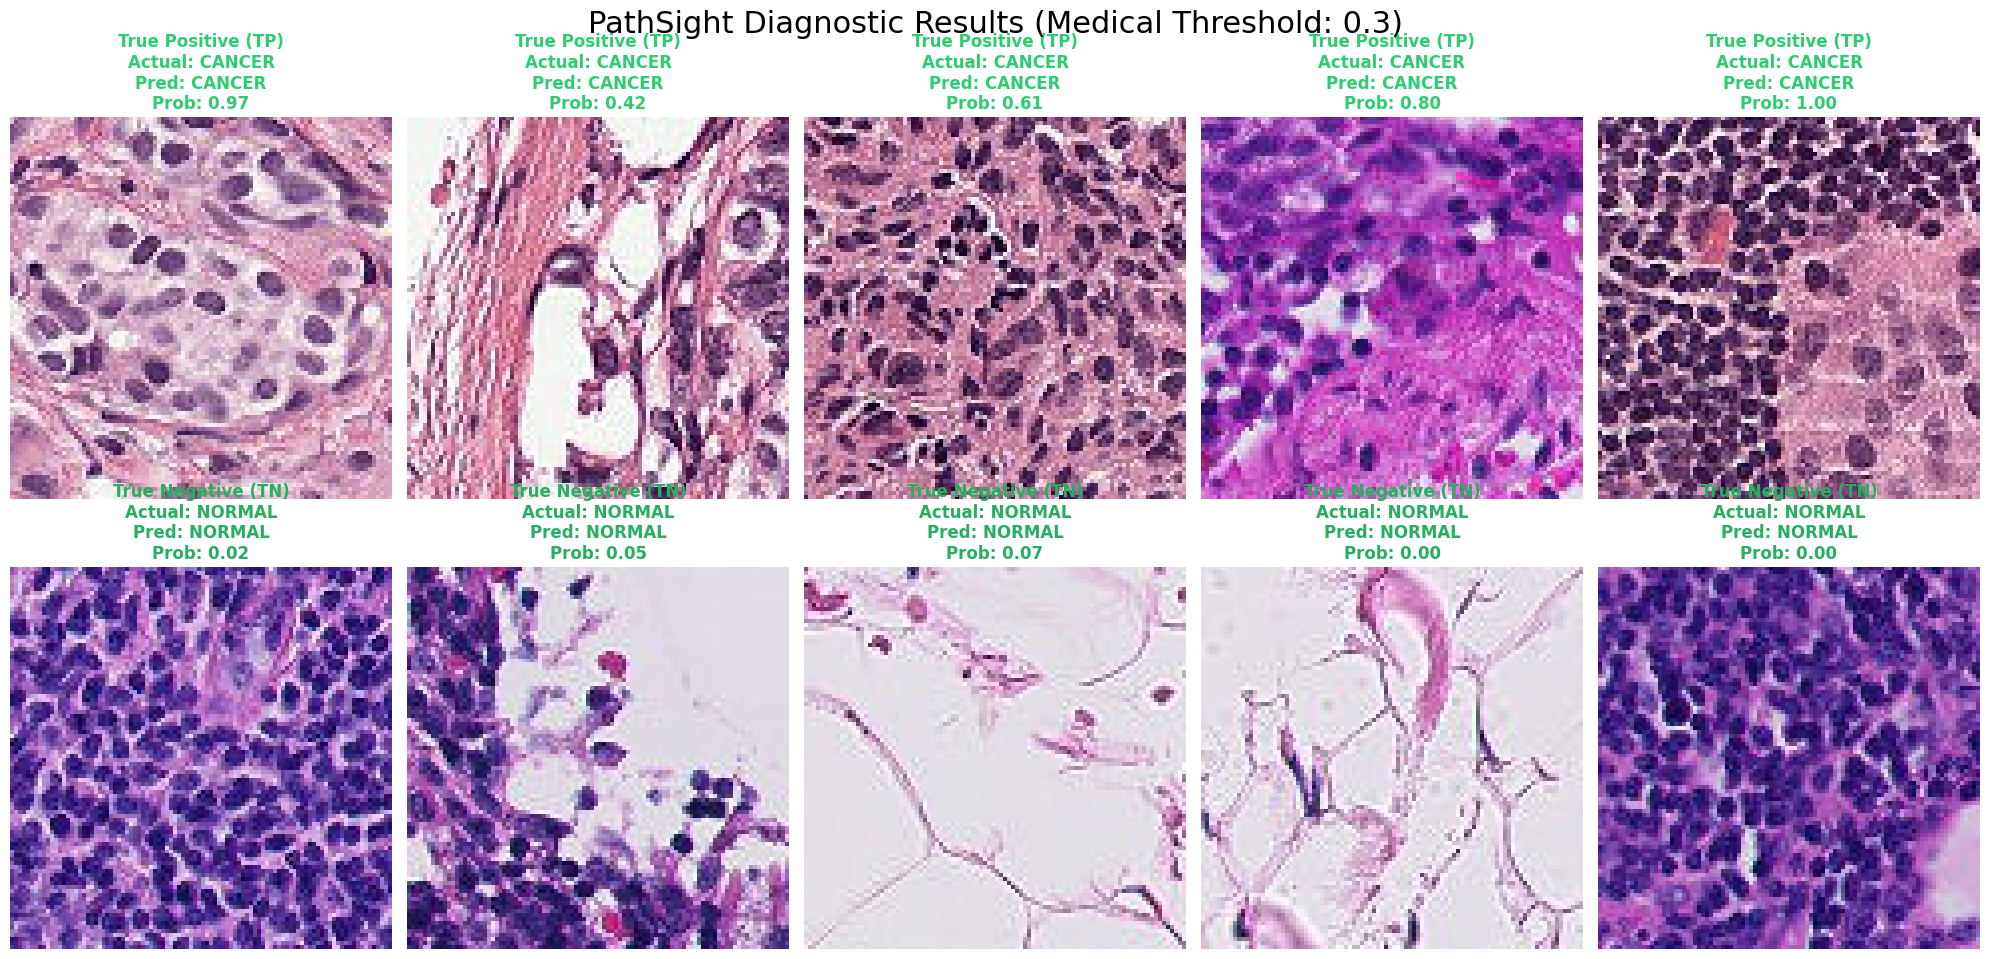

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Grab fresh samples
cancer_imgs, healthy_imgs = [], []
print("🔎 Extracting clear samples from test_ds...")

for img, label in test_ds.unbatch():
    if label == 1 and len(cancer_imgs) < 5:
        cancer_imgs.append(img)
    elif label == 0 and len(healthy_imgs) < 5:
        healthy_imgs.append(img)
    if len(cancer_imgs) == 5 and len(healthy_imgs) == 5:
        break

X_samples = tf.stack(cancer_imgs + healthy_imgs)
y_true = np.array([1]*5 + [0]*5)
preds = model.predict(X_samples, verbose=0)

# 2. Plotting
plt.figure(figsize=(20, 10))
threshold = 0.3  # Using the safer threshold we discussed

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # --- FIXED IMAGE DISPLAY ---
    # Convert to numpy and ensure values are exactly in [0, 1] for plt.imshow
    raw_img = X_samples[i].numpy()
    # Rescale specifically for visualization
    display_img = (raw_img - raw_img.min()) / (raw_img.max() - raw_img.min() + 1e-7)
    plt.imshow(display_img)

    # --- FIXED PREDICTION LOGIC ---
    prob = float(preds[i][0]) # This now correctly grabs the prob for image 'i'
    is_cancer_pred = prob > threshold
    is_cancer_true = y_true[i] == 1

    if is_cancer_pred and is_cancer_true:
        term, color = "True Positive (TP)", "#2ecc71" # Professional Green
    elif not is_cancer_pred and not is_cancer_true:
        term, color = "True Negative (TN)", "#27ae60"
    elif is_cancer_pred and not is_cancer_true:
        term, color = "False Positive (FP)", "#e74c3c" # Professional Red
    else:
        term, color = "False Negative (FN)", "#c0392b"

    plt.title(f"{term}\nActual: {'CANCER' if is_cancer_true else 'NORMAL'}\nPred: {'CANCER' if is_cancer_pred else 'NORMAL'}\nProb: {prob:.2f}",
              color=color, fontsize=12, fontweight='bold')
    plt.axis('off')

plt.suptitle(f"PathSight Diagnostic Results (Medical Threshold: {threshold})", fontsize=22, y=0.98)
plt.tight_layout()
plt.show()

In [35]:
# Evaluate on the full unseen test dataset
results = model.evaluate(test_ds, return_dict=True)

print(f"📈 Full Test AUC: {results['auc']:.4f}")
print(f"🔍 Full Test Recall: {results['recall']:.4f}")
print(f"🎯 Full Test Accuracy: {results['accuracy']:.4f}")
print(f"⚠️ Full Test Loss: {results['loss']:.4f}")
print(f"🔍 Full Test Precision: {results['precision']:.4f}")

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.8042 - auc: 0.9137 - loss: 0.5123 - precision: 0.9232 - recall: 0.6611
📈 Full Test AUC: 0.9138
🔍 Full Test Recall: 0.6615
🎯 Full Test Accuracy: 0.8043
⚠️ Full Test Loss: 0.5178
🔍 Full Test Precision: 0.9257


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━

2026-04-27 23:24:34.536913: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


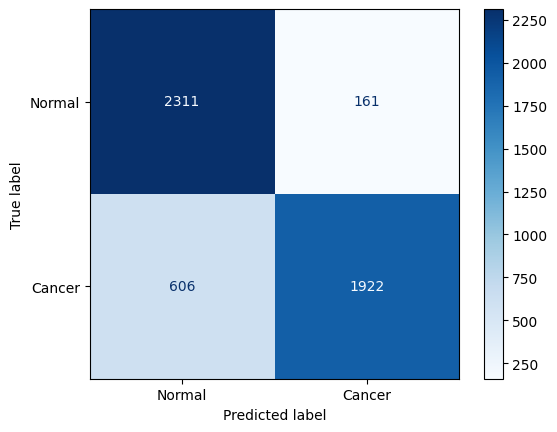

In [36]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Get all labels and predictions from the validation set
y_true = []
y_pred_probs = []

for images, labels in val_ds.take(1000): # Taking a subset for speed
    preds = model.predict(images)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# 2. Start with a standard 0.5 threshold
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Cancer'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [22]:
from sklearn.metrics import classification_report

# Try a more "sensitive" threshold for medical safety
threshold = 0.3
y_pred_tuned = (y_pred_probs > threshold).astype(int)

print(f"--- Results with Threshold: {threshold} ---")
print(classification_report(y_true, y_pred_tuned, target_names=['No Cancer', 'Cancer']))

--- Results with Threshold: 0.3 ---
              precision    recall  f1-score   support

   No Cancer       0.87      0.87      0.87       171
      Cancer       0.85      0.85      0.85       149

    accuracy                           0.86       320
   macro avg       0.86      0.86      0.86       320
weighted avg       0.86      0.86      0.86       320



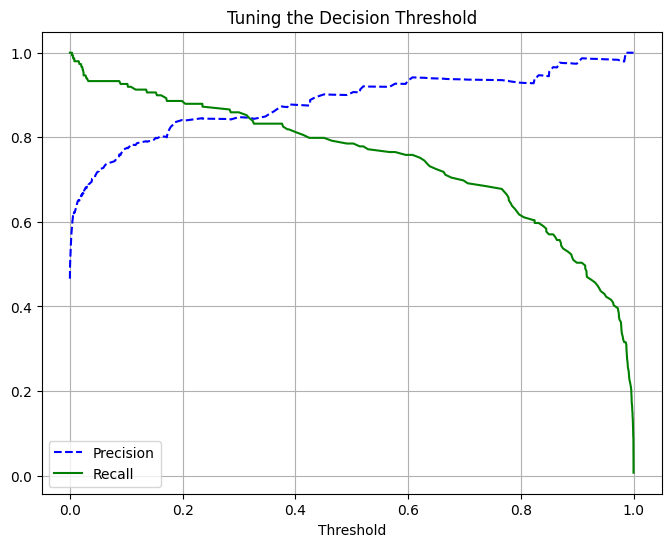

In [20]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_true, y_pred_probs)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.title("Tuning the Decision Threshold")
plt.legend()
plt.grid()
plt.show()